# Deadline-basert backtest: datadekning og beslutningsnytte

Denne notebooken kjører først evidenskontrollen for 2022–23 til 2025–26. Perioder uten dokumentert deadline, spillerregister, kampoppsett og kampvis historikk utelates. Manglende dekning skal ikke gi simulerte modellresultater.

**Denne leveransen følger planens datarapport-alternativ:** Arkivene vi undersøkte gir bootstrap-snapshots før deadline, men ikke et verifisert komplett grunnlag for fixture- og historikkdata. Derfor trenes ingen deadline-modell i denne kjøringen. Tidligere kampbaserte resultater er ikke deadline-resultater.

Bruk prosjektets `.venv` og Run All. Kildene er hentet separat med `python src/deadline_audit.py`; denne notebooken leser siste lagrede revisjon uten nye nettverkskall.

In [1]:
from pathlib import Path
import sys, json, tempfile
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/deadline_audit.py').exists())
sys.path.insert(0, str(ROOT/'src'))
from deadline_audit import latest, sha256
audit_dir = latest(ROOT)
coverage = pd.read_csv(audit_dir/'coverage.csv')
settings = json.loads((audit_dir/'settings.json').read_text())
assert len(coverage) == 152
assert not coverage.duplicated(['season','GW']).any()
print('Kilderevisjon:', audit_dir)
display(pd.Series(settings).to_frame('verdi'))

Kilderevisjon: /Users/henrik/Documents/fplmodell/data/raw/deadline_audit/audit_7l7i2pad


,verdi
repository,beeradb/FPL-Armband
commit,b18295ee55069fedb9766e2b08c3eb3c23cea65b
seasons,"[2022-23, 2023-24, 2024-25, 2025-26]"
policy,strict pre-deadline evidence; no end-of-season...
status,DATA_REPORT_ONLY
approved_gameweeks,0
note,Fixture/history coverage is not established by...


## Kilder og proveniens

Bootstrap-arkivet [FPL-Armband](https://github.com/beeradb/FPL-Armband/blob/main/docs/backfill.md) peker til Internet Archive og lagrer capture-tid, payload-hash og event-deadline. Revisjonen pinner repository-commit og kontrollerer disse opplysningene mot selve payloaden. Det er ikke en uavhengig gjeninnhenting av alle Wayback-captures.

[Randdalf/fplcache](https://github.com/Randdalf/fplcache) arkiverer bootstrap-endepunktet. [TopMarx/fpl](https://github.com/TopMarx/fpl) og [vaastav](https://github.com/vaastav/Fantasy-Premier-League) ble også undersøkt; deres nåværende historiske filer er ikke automatisk dokumentasjon på verdiene ved hver deadline.

`downloaded_at` er innhenting nå. `captured_at` er arkivets dokumenterte capture-tid. Bare sistnevnte kan inngå i tidskontrollen. Lokale råbytes og SHA-256 lagres sammen med URL og status.

In [2]:
records=[]
for path in sorted((audit_dir/'evidence').glob('*.json')):
    record=json.loads(path.read_text())
    raw_path=Path(record['path'])
    if raw_path.exists() and 'sha256' in record:
        assert sha256(raw_path.read_bytes()) == record['sha256'], raw_path
    records.append(record)
evidence=pd.DataFrame(records)
print('Antall innhentede kildeobjekter:',len(evidence))
display(evidence[['url','downloaded_at','available_at','status']].head(12))
display(coverage[['season','GW','deadline','captured_at','snapshot_age_hours','players']].head(12))

Antall innhentede kildeobjekter: 322


,url,downloaded_at,available_at,status
0,https://raw.githubusercontent.com/beeradb/FPL-...,2026-09-08T09:41:15.843085+00:00,None,200
1,https://raw.githubusercontent.com/beeradb/FPL-...,2026-09-08T09:40:58.895870+00:00,None,200
2,https://raw.githubusercontent.com/beeradb/FPL-...,2026-09-08T09:40:57.782852+00:00,None,200
3,https://raw.githubusercontent.com/beeradb/FPL-...,2026-09-08T09:40:59.476172+00:00,None,200
4,https://raw.githubusercontent.com/beeradb/FPL-...,2026-09-08T09:40:52.259830+00:00,None,200
5,https://raw.githubusercontent.com/beeradb/FPL-...,2026-09-08T09:41:15.601841+00:00,None,200
6,https://raw.githubusercontent.com/beeradb/FPL-...,2026-09-08T09:40:53.135544+00:00,None,200
7,https://raw.githubusercontent.com/beeradb/FPL-...,2026-09-08T09:41:04.095378+00:00,None,200
8,https://raw.githubusercontent.com/beeradb/FPL-...,2026-09-08T09:41:00.056183+00:00,None,200
9,https://raw.githubusercontent.com/beeradb/FPL-...,2026-09-08T09:41:09.054902+00:00,None,200


,season,GW,deadline,captured_at,snapshot_age_hours,players
0,2022-23,1,2022-08-05T17:30:00+00:00,2022-08-05T17:16:51+00:00,0.219167,559
1,2022-23,2,2022-08-13T10:00:00+00:00,2022-08-11T20:52:44+00:00,37.121111,580
2,2022-23,3,2022-08-20T10:00:00+00:00,2022-08-20T08:46:47+00:00,1.220278,589
3,2022-23,4,2022-08-27T10:00:00+00:00,2022-08-27T08:48:20+00:00,1.194444,594
4,2022-23,5,2022-08-30T17:00:00+00:00,2022-08-29T21:30:00+00:00,19.500000,601
5,2022-23,6,2022-09-03T10:00:00+00:00,2022-09-03T09:32:15+00:00,0.462500,623
6,2022-23,7,2022-09-10T10:00:00+00:00,2022-09-09T08:47:09+00:00,25.214167,624
7,2022-23,8,2022-09-16T17:30:00+00:00,2022-09-16T07:51:51+00:00,9.635833,627
8,2022-23,9,2022-10-01T10:00:00+00:00,2022-09-26T10:13:50+00:00,119.769444,631
9,2022-23,10,2022-10-08T12:30:00+00:00,2022-10-07T21:37:54+00:00,14.868333,638


## Godkjente og utelatte runder

Bootstrap-dekning er nødvendig, men ikke tilstrekkelig. Kalenderen må komme fra det historiske payloadet, ikke beregnes fra endelig kickoff. Gamle snapshots kan også være utdaterte; alder vises eksplisitt og de godkjennes ikke som et komplett deadline-grunnlag.

,deadline_verified,registry_verified,fixtures_verified,history_verified,approved
season,,,,,
2022-23,38,38,0,0,0
2023-24,38,38,0,0,0
2024-25,38,38,0,0,0
2025-26,38,38,0,0,0


,season,GW,excluded_reason
0,2022-23,1,no_verified_pre_deadline_fixture_snapshot; no_...
1,2022-23,2,no_verified_pre_deadline_fixture_snapshot; no_...
2,2022-23,3,no_verified_pre_deadline_fixture_snapshot; no_...
3,2022-23,4,no_verified_pre_deadline_fixture_snapshot; no_...
4,2022-23,5,no_verified_pre_deadline_fixture_snapshot; no_...
...,...,...,...
147,2025-26,34,no_verified_pre_deadline_fixture_snapshot; no_...
148,2025-26,35,no_verified_pre_deadline_fixture_snapshot; no_...
149,2025-26,36,no_verified_pre_deadline_fixture_snapshot; no_...
150,2025-26,37,no_verified_pre_deadline_fixture_snapshot; no_...


,min,median,max
season,,,
2022-23,0.06,7.29,119.77
2023-24,0.40,6.12,14.80
2024-25,0.01,5.75,562.85
2025-26,0.13,4.73,18.49


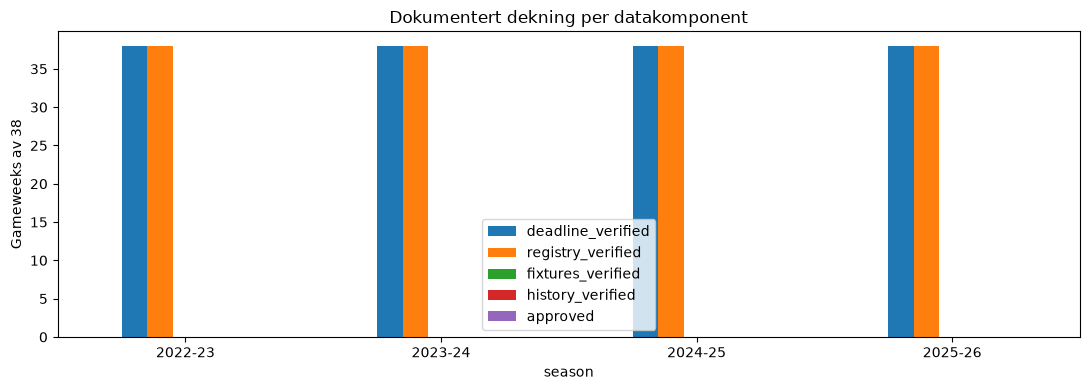

In [3]:
summary=coverage.groupby('season')[['deadline_verified','registry_verified','fixtures_verified','history_verified','approved']].sum()
display(summary)
summary.plot.bar(figsize=(11,4))
plt.ylabel('Gameweeks av 38'); plt.title('Dokumentert dekning per datakomponent')
plt.xticks(rotation=0); plt.tight_layout()
display(coverage[['season','GW','excluded_reason']])
display(coverage.groupby('season').snapshot_age_hours.agg(['min','median','max']).round(2))

## Feature- og evalueringspipeline

`src/deadline_features.py` rekonstruerer 34 grunnvariabler og ensemblets ekstra variabler fra normaliserte arkivversjoner. Først velges siste versjon tilgjengelig før deadline, så filtreres kampoppsett på gameweek. Dette håndterer flyttede kamper. Spillerhistorikken fryses én gang og gjenbrukes i alle rundens kamper. Blanke runder får eksplisitte rader, og nye spillere får NaN for ukjent historikk.

`src/deadline_evaluation.py` inneholder de låste metodene form, HGB og ensemble, spiller–gameweek-aggregering, segmentering, topp-k, kaptein og parvis bootstrap. Fasiten er separat, og ukjente utfall blir ikke erstattet med null.

Disse modulene er testet med syntetiske tidslinjer. Import av flere historiske kildeformater og kobling til godkjente produksjonsrunder krever fortsatt dokumenterte fixture-/historikk-snapshots. Et `audit_approved`-felt alene er ikke kildebevis.

In [4]:
approved=coverage[coverage.approved.eq(True)]
if approved.empty:
    print('DATA_REPORT_ONLY: 0 godkjente runder. Ingen modeller trenes eller scores.')
    print('Mangler: kampoppsett kjent før deadline og versjonert kampvis spiller-/laghistorikk.')
    print('Ingen tidligere testscore gjenbrukes som deadline-resultat.')
else:
    raise RuntimeError('Nye godkjente kilder krever en kontrollert normaliseringsadapter før trening.')

DATA_REPORT_ONLY: 0 godkjente runder. Ingen modeller trenes eller scores.
Mangler: kampoppsett kjent før deadline og versjonert kampvis spiller-/laghistorikk.
Ingen tidligere testscore gjenbrukes som deadline-resultat.


## Videre datasteg og planlagt sammenligning

1. Skaff arkiverte fixtures og kampvise historikkversjoner med dokumentert tilgjengelighet. Undersøk historiske commits og capture-arkiver; godkjenn ikke endelige sesongfiler bare fordi kampene allerede var spilt.
2. Normaliser råkildene til modulenes eksplisitte tabellgrensesnitt og knytt hver versjon til kildebevis. Bekreft komplett spillerregister og separat spiller–gameweek-fasit.
3. Kjør 2022–23 → 2023–24 og 2022–24 → 2024–25 med de låste metodene. Refit på 2022–25 og evaluer 2025–26, som allerede er undersøkt historisk. Samme runder/spillere for alle modeller.
4. Rapporter spiller–gameweek MAE/RMSE, kalibrering, rangering, historisk 60+-segment og kapteinsgevinst mot form. Ingen budsjett, transfers, visekaptein eller chips.

Før disse stegene er fullført kan vi ikke si om ensemblet forbedrer faktiske deadline-valg.

In [5]:
report_parent=ROOT/'artifacts/deadline_backtests'
report_parent.mkdir(parents=True,exist_ok=True)
report_dir=Path(tempfile.mkdtemp(prefix='coverage_',dir=report_parent))
coverage.to_csv(report_dir/'coverage.csv',index=False)
summary.to_csv(report_dir/'coverage_summary.csv')
evidence.to_csv(report_dir/'source_index.csv',index=False)
(report_dir/'status.json').write_text(json.dumps({
    'status':'DATA_REPORT_ONLY','approved_gameweeks':len(approved),
    'audit_dir':str(audit_dir),'source_commit':settings['commit'],
    'models_trained':False,'metrics_generated':False},indent=2))
print('Rapport lagret:',report_dir)

Rapport lagret: /Users/henrik/Documents/fplmodell/artifacts/deadline_backtests/coverage_6je4m5_p
